# A-Phased Repeats — SNP frequency, **detected only** (Supplementary code 2 §6)

Same pipeline as `apr_snp_frequency_notebook.ipynb` but the input is the **gofae model's detected APR** (`A_Phased_Repeat_detected.bed`, ~3912 rows) instead of all `label == 'A_Phased_Repeat'` rows from the test CSV (~140624 rows). Everything downstream (NCNR filter, 100-bp threshold, flanks, controls, locuschoice, 7-part split, intersect, IWTomics, plot) is unchanged.

The motif sequence is read from the detected BED's `sequence` column directly (not from a `features=` string). Tracts are then detected with the same regex cascade (`A{3,}` → `T{3,}` → `A{2,}` → `T{2,}`)."

# Library

In [1]:
try:
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    print('rpy2 loaded')
except Exception as e:
    print('rpy2 not available (R cells will fail, which is expected for the pipeline-only run):', e)

rpy2 not available (R cells will fail, which is expected for the pipeline-only run): No module named 'rpy2'


# 6. A-Phased Repeats (detected)

## Setup

All intermediate files are written into `results/apr_notebook_detected_run/`.

In [20]:
import os, sys, re, subprocess, random
from pathlib import Path
import pandas as pd
import numpy as np

BASE    = os.environ.get("SNP_AF_BASE", "/path/to/snp_af_analysis")
WORKDIR = f"{BASE}/results/apr_notebook_detected_run"
Path(WORKDIR).mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

os.environ["BASE"]        = BASE
os.environ["CHROM_SIZES"] = f"{BASE}/reference/hg38.chrom.sizes"
os.environ["GAPS_BED"]    = f"{BASE}/annotations/hg38_gaps.bed"
os.environ["CODING_BED"]  = f"{BASE}/annotations/coding_regions.bed"
os.environ["REPEAT_BED"]  = f"{BASE}/annotations/repetitive_elements.bed"
os.environ["SNP_DIR"]     = f"{BASE}/snp_data/gnomad"
os.environ["PATH"]        = os.environ.get("BEDTOOLS_BIN", "") + ":" + os.environ["PATH"]
# Stage-1 (NR-Contrastive) outputs and experimental splits
# Override with environment variables; the defaults are the paths used for the paper.
PU_RESULTS      = os.environ.get("NONB_PU_RESULTS",
    "/path/to/pu_results")
EXPERIMENT_DATA = os.environ.get("NONB_EXPERIMENT_DATA",
    "/path/to/Experiment_Data")
IWTOMICS_DIR    = os.environ.get("IWTOMICS_DIR",
    "/path/to/nonb-nrcl-paper/snp_analysis/iwtomics")


random.seed(42); np.random.seed(42)
print("cwd:", os.getcwd())
print("bedtools:", subprocess.run("which bedtools", shell=True, capture_output=True, text=True).stdout.strip())

cwd: /data/haotian/qianying/snp_af_analysis/results/apr_notebook_detected_run
bedtools: /home/haz19024/softwares/bedtools2/bin/bedtools


## 6.1 Retrieve annotation + tract detection (detected)

Load gofae model's **detected** APR windows from `A_Phased_Repeat_detected.bed`. Columns: `chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value`. Convert 1-based inclusive coords to 0-based half-open. The motif `sequence` is its own column here (no `features=` string), then tract boundaries are detected with the same regex cascade.

Output is a 4-col BED that mirrors the published `NCNR.APhasedRepeats.split.bed` format: `chrom, motif_start, motif_end, "s1|e1,s2|e2,s3|e3,"` (sections relative to motif start).

In [21]:
APR_BED = f"{PU_RESULTS}/A_Phased_Repeat/A_Phased_Repeat_detected.bed"

# Detected BED columns: chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value
df = pd.read_csv(APR_BED, sep="\t")
print(f"detected APR rows: {len(df)}")

df = df.dropna(subset=["motif_start","motif_end","sequence"]).reset_index(drop=True)
df["motif_start"] = df["motif_start"].astype(int) - 1   # 1-based inclusive -> 0-based half-open
df["motif_end"]   = df["motif_end"].astype(int)
df = df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

df["seq"] = df["sequence"].astype(str)
print(f"with sequence: {len(df)}")

detected APR rows: 3911
with sequence: 3911


In [22]:
# Tract detector — cascade regex.
# Picks the first 3 non-overlapping runs of A's (or T's on the reverse strand).
# Returns list of 3 (start, end) tuples relative to the motif sequence, or None.
_TRACT_PATTERNS = [
    re.compile(r"[Aa]{3,}"), re.compile(r"[Tt]{3,}"),
    re.compile(r"[Aa]{2,}"), re.compile(r"[Tt]{2,}"),
]

def find_tracts(seq):
    for pat in _TRACT_PATTERNS:
        runs = [(m.start(), m.end()) for m in pat.finditer(seq)]
        if len(runs) >= 3:
            return runs[:3]
    return None

tract_results = df["seq"].apply(find_tracts)
df["tracts"] = tract_results
n_total = len(df)
df = df[df["tracts"].notna()].reset_index(drop=True)
print(f"loci with 3 tracts found: {len(df)}/{n_total} ({100*len(df)/n_total:.1f}%)")

# Build sections string (relative to motif_start). The published format is:
#   "s1|e1,s2|e2,s3|e3,"
# where each pair is one tract.
df["sections"] = df["tracts"].apply(
    lambda runs: ",".join(f"{s}|{e}" for (s,e) in runs) + ","
)

# Apply 100-bp motif length filter (per published `awk '$3-$2<=100 && $4==3'`)
df["motif_len"] = df["motif_end"] - df["motif_start"]
df = df[df["motif_len"] <= 100].reset_index(drop=True)
print(f"after motif-length<=100 filter: {len(df)}")

df[["chr","motif_start","motif_end","sections"]].to_csv(
    "NCNR.APhasedRepeats.split.bed", sep="\t", header=False, index=False)
print("wrote NCNR.APhasedRepeats.split.bed")

loci with 3 tracts found: 3701/3911 (94.6%)
after motif-length<=100 filter: 3701
wrote NCNR.APhasedRepeats.split.bed


Apply NCNR filter (remove overlaps with coding ∪ repetitive). Sort.

In [23]:
%%bash
set -euo pipefail

if [ ! -f NCNR.hg38.bed ]; then
    cat "$CODING_BED" "$REPEAT_BED" | sort -k1,1 -k2,2n | bedtools merge -i stdin > NCNR.hg38.bed
fi

bedtools intersect -a NCNR.APhasedRepeats.split.bed -b NCNR.hg38.bed -v > _NCNR.APhasedRepeats.split.ncnr.bed
bedtools sort -i _NCNR.APhasedRepeats.split.ncnr.bed > NCNR.APhasedRepeats.split.sorted.bed
rm -f _NCNR.APhasedRepeats.split.ncnr.bed

wc -l NCNR.APhasedRepeats.split.bed NCNR.APhasedRepeats.split.sorted.bed
head -2 NCNR.APhasedRepeats.split.sorted.bed

  3701 NCNR.APhasedRepeats.split.bed
   392 NCNR.APhasedRepeats.split.sorted.bed
  4093 total
chr1	38500407	38500432	0|4,12|15,22|25,
chr1	38727107	38727130	1|3,10|13,15|17,


## 6.2 Create Flanks

Add 2 kb flanks. 8-col output: `chrom, f_start, f_end, motif_len, +, l_start, l_end, sections`.

In [24]:
%%bash
set -euo pipefail
paste NCNR.APhasedRepeats.split.sorted.bed \
    <(bedtools slop -i NCNR.APhasedRepeats.split.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNRAPhasedRepeats.flanked.bed

wc -l NCNRAPhasedRepeats.flanked.bed
head -2 NCNRAPhasedRepeats.flanked.bed

392 NCNRAPhasedRepeats.flanked.bed
chr1	38498407	38502432	25	+	38500407	38500432	0|4,12|15,22|25,
chr1	38725107	38729130	23	+	38727107	38727130	1|3,10|13,15|17,


## 6.3 Create Controls

Shuffle exclusion = all-APR ∪ NCNR ∪ hg38_gaps. The shuffled control inherits the same `sections` string from the source motif (controls don't have their own tract structure — they get the same scaffolding so the split step has something to read). Then 2 kb flanks are added.

In [26]:
%%bash
set -euo pipefail

cut -f 1-3 NCNR.APhasedRepeats.split.sorted.bed > _temp_APR

cat _temp_APR "$GAPS_BED" NCNR.hg38.bed \
  | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_APR.bed

# bedtools shuffle preserves columns 1-3 only; we re-attach the original sections column afterwards
# by joining on row order (since shuffle keeps the same row count).
bedtools shuffle -i NCNR.APhasedRepeats.split.sorted.bed \
    -excl exclude_APR.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 42 > _shuffled.bed

# Recover original column 4 (sections) by line
paste <(cut -f1-3 _shuffled.bed) <(cut -f4 NCNR.APhasedRepeats.split.sorted.bed) > _shuffled.with_sections.bed

bedtools sort -i _shuffled.with_sections.bed > NCNRAPhasedRepeats.ctrl.bed

paste NCNRAPhasedRepeats.ctrl.bed \
    <(bedtools slop -i NCNRAPhasedRepeats.ctrl.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNRAPhasedRepeats.ctrl.flanked.bed

rm -f _temp_APR _shuffled.bed _shuffled.with_sections.bed
wc -l NCNRAPhasedRepeats.ctrl.flanked.bed
head -2 NCNRAPhasedRepeats.ctrl.flanked.bed

392 NCNRAPhasedRepeats.ctrl.flanked.bed
chr1	4386045	4390071	26	+	4388045	4388071	0|4,5|7,11|13,
chr1	12768874	12772899	25	+	12770874	12770899	0|3,11|14,22|25,


## 6.4 Pick non-overlapping windows

In [27]:
def locuschoice(in_bed, out_bed, seed=42):
    rng = random.Random(seed)
    last_chrom = "chr0"; last_end = 0; tochoose = []; nkept = 0
    with open(in_bed) as f_in, open(out_bed, "w") as f_out:
        for line in f_in:
            arr = line.rstrip("\n").split("\t")
            chrom = arr[0]; ws = int(arr[1]); we = int(arr[2])
            if chrom == last_chrom:
                if ws < last_end:
                    tochoose.append(arr); last_end = we
                else:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                    tochoose = [arr]; last_end = we
            else:
                if tochoose:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                tochoose = [arr]; last_chrom = chrom; last_end = we
        if tochoose:
            chosen = tochoose[rng.randint(0, len(tochoose)-1)]
            f_out.write("\t".join(chosen) + "\n"); nkept += 1
    print(f"{in_bed} -> {out_bed}: kept {nkept}")
    return nkept

locuschoice("NCNRAPhasedRepeats.flanked.bed",      "NCNRAPhasedRepeats.nooverlap.bed",      seed=42)
locuschoice("NCNRAPhasedRepeats.ctrl.flanked.bed", "NCNRAPhasedRepeats.ctrl.nooverlap.bed", seed=43)

NCNRAPhasedRepeats.flanked.bed -> NCNRAPhasedRepeats.nooverlap.bed: kept 392
NCNRAPhasedRepeats.ctrl.flanked.bed -> NCNRAPhasedRepeats.ctrl.nooverlap.bed: kept 392


392

## 6.5 Split Tracts, Spacer, and Flanks

Refactor of the published `APhasedSections.py`. Each window splits into 7 parts:
`LeftFlank | Tract1 | Spacer1 | Tract2 | Spacer2 | Tract3 | RightFlank`.
Output is 5 columns: `chrom, start, end, locus_id, part_type`.

In [28]:
def split_apr(in_bed, out_bed):
    """Mirrors APhasedSections.py (Supplementary code 2 §6.4).
    Input columns (8): chrom, f_start, f_end, length, strand, l_start, l_end, sections
    sections format: "s1|e1,s2|e2,s3|e3," (relative to l_start)
    """
    loci = 0; skipped = 0
    with open(in_bed) as fin, open(out_bed, "w") as fout:
        for line in fin:
            parts = line.rstrip("\n").split("\t")
            chrom, f_start, f_end, _length, _strand, l_start, l_end, sections = parts[:8]
            secs = sections.split(",")
            secs = [s for s in secs if s]
            if len(secs) < 3:
                skipped += 1; continue
            try:
                t1s, t1e = (int(x) for x in secs[0].split("|"))
                t2s, t2e = (int(x) for x in secs[1].split("|"))
                t3s, t3e = (int(x) for x in secs[2].split("|"))
            except ValueError:
                skipped += 1; continue
            ls = int(l_start)
            T1s, T1e = ls + t1s, ls + t1e
            S1s, S1e = T1e,       ls + t2s
            T2s, T2e = ls + t2s,  ls + t2e
            S2s, S2e = T2e,       ls + t3s
            T3s, T3e = ls + t3s,  ls + t3e
            if not (T1s < T1e <= S1e and S1s <= S1e <= T2s and T2s < T2e <= S2e and S2s <= S2e <= T3s and T3s < T3e):
                skipped += 1; continue
            lid = loci; loci += 1
            fout.write(f"{chrom}\t{f_start}\t{ls}\t{lid}\tLeftFlank\n")
            fout.write(f"{chrom}\t{T1s}\t{T1e}\t{lid}\tTract1\n")
            fout.write(f"{chrom}\t{S1s}\t{S1e}\t{lid}\tSpacer1\n")
            fout.write(f"{chrom}\t{T2s}\t{T2e}\t{lid}\tTract2\n")
            fout.write(f"{chrom}\t{S2s}\t{S2e}\t{lid}\tSpacer2\n")
            fout.write(f"{chrom}\t{T3s}\t{T3e}\t{lid}\tTract3\n")
            fout.write(f"{chrom}\t{l_end}\t{f_end}\t{lid}\tRightFlank\n")
    print(f"{in_bed} -> {out_bed}: {loci} Loci, skipped={skipped}")
    return loci

n_motif = split_apr("NCNRAPhasedRepeats.nooverlap.bed",      "NCNRAPhasedRepeats.sections.bed")
n_ctrl  = split_apr("NCNRAPhasedRepeats.ctrl.nooverlap.bed", "NCNRAPhasedRepeats.ctrl.sections.bed")

N_MOTIF, N_CTRL = n_motif, n_ctrl
print(f"\nN_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")
with open("split_counts.txt","w") as f:
    f.write(f"N_MOTIF\t{N_MOTIF}\nN_CTRL\t{N_CTRL}\n")

NCNRAPhasedRepeats.nooverlap.bed -> NCNRAPhasedRepeats.sections.bed: 392 Loci, skipped=0
NCNRAPhasedRepeats.ctrl.nooverlap.bed -> NCNRAPhasedRepeats.ctrl.sections.bed: 392 Loci, skipped=0

N_MOTIF=392  N_CTRL=392


## 6.6 Intersect annotations with variation datasets

Per-chromosome intersect with gnomAD.

In [29]:
def intersect_per_chrom(bed_path, out_path):
    snp_dir = os.environ["SNP_DIR"]
    chroms = sorted(pd.read_csv(bed_path, sep="\t", header=None)[0].unique())
    total = 0
    with open(out_path,"w") as fout:
        for c in chroms:
            snp_file = f"{snp_dir}/{c}_snps.bed"
            if not os.path.exists(snp_file):
                print(f"  skip {c} (no {snp_file})"); continue
            cmd = (f'awk \'$1=="{c}"\' {bed_path} '
                   f'| bedtools intersect -wa -wb -a stdin -b {snp_file} -loj')
            res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            if res.stdout:
                fout.write(res.stdout); total += res.stdout.count("\n")
    print(f"{bed_path} -> {out_path}: {total} lines")
    return total

for p in ("NCNRAPhasedRepeats.sections.bed", "NCNRAPhasedRepeats.ctrl.sections.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("NCNRAPhasedRepeats.sections.bed",      "NCNRAPhasedRepeats.gnomAD.intersect")
intersect_per_chrom("NCNRAPhasedRepeats.ctrl.sections.bed", "NCNRAPhasedRepeats.gnomAD.ctrl.intersect")

NCNRAPhasedRepeats.sections.bed -> NCNRAPhasedRepeats.gnomAD.intersect: 401836 lines
NCNRAPhasedRepeats.ctrl.sections.bed -> NCNRAPhasedRepeats.gnomAD.ctrl.intersect: 399753 lines


399753

## 6.7 Plot Results (Python / matplotlib)

1. IWTomics permutation test (1000 perms, α = 0.01, min run = 5) on the per-locus count matrices.
2. 7-panel log-scale scatter (Left flank | Tract1 | Spacer1 | Tract2 | Spacer2 | Tract3 | Right flank). Tracts are scaled to **40 bins**, spacers to **30 bins**, matching the published R plot.

In [38]:
MAX_FLANK    = 100
TRACT_BINS   = 40
SPACER_BINS  = 30
CENTER_BINS  = 3*TRACT_BINS + 2*SPACER_BINS   # 180
N_PERM       = 1000
ALPHA        = 0.01

scaledposTract  = [round(i,4) for i in np.arange(1, TRACT_BINS*2,  2.0)/(TRACT_BINS*2)]
scaledposSpacer = [round(i,4) for i in np.arange(1, SPACER_BINS*2, 2.0)/(SPACER_BINS*2)]

PART_OFFSETS = {
    "Tract1":  0,
    "Spacer1": TRACT_BINS,
    "Tract2":  TRACT_BINS + SPACER_BINS,
    "Spacer2": 2*TRACT_BINS + SPACER_BINS,
    "Tract3":  2*TRACT_BINS + 2*SPACER_BINS,
}
PART_LEN = {
    "Tract1":  TRACT_BINS,  "Spacer1": SPACER_BINS,
    "Tract2":  TRACT_BINS,  "Spacer2": SPACER_BINS,
    "Tract3":  TRACT_BINS,
}

def _build_matrices(intersect_path, n_loci):
    left_mat   = np.zeros((n_loci, MAX_FLANK),   dtype=np.float32)
    center_mat = np.zeros((n_loci, CENTER_BINS), dtype=np.float32)
    right_mat  = np.zeros((n_loci, MAX_FLANK),   dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            lid   = int(f[3])
            ps    = int(f[1]); pe = int(f[2])
            ptype = f[4]
            if len(f) >= 6 and f[5] == ".": continue
            snp_start = int(f[6])
            plen = pe - ps
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            if ptype == "LeftFlank":
                coord = -(pe - snp_start)
                idx = coord + MAX_FLANK
                if 0 <= idx < MAX_FLANK:
                    left_mat[lid, idx] += 1
            elif ptype == "RightFlank":
                coord = snp_start - ps
                if 0 <= coord < MAX_FLANK:
                    right_mat[lid, coord] += 1
            elif ptype in PART_OFFSETS:
                if plen == 0: continue
                off = PART_OFFSETS[ptype]
                sp_list = scaledposTract if ptype.startswith("Tract") else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(sp_list):
                    if sp >= fs and sp < fe:
                        center_mat[lid, off + i] += 1
    return left_mat, center_mat, right_mat


def iwtomics(data1, data2, n_perm=N_PERM, alpha=ALPHA, seed=42):
    n1, p = data1.shape; n2 = data2.shape[0]; n = n1 + n2
    all_data = np.vstack([data1, data2])
    obs_t = (data1.mean(0) - data2.mean(0)) ** 2
    perm_t = np.zeros((n_perm, p), dtype=np.float64)
    rng = np.random.default_rng(seed)
    for b in range(n_perm):
        idx = rng.permutation(n)
        m1 = all_data[idx[:n1]].mean(0); m2 = all_data[idx[n1:]].mean(0)
        perm_t[b] = (m1 - m2) ** 2
    unadj_p = (np.sum(perm_t >= obs_t[None, :], axis=0) + 1) / (n_perm + 1)
    obs_cum  = np.concatenate([[0], np.cumsum(obs_t)])
    perm_cum = np.hstack([np.zeros((n_perm, 1)), np.cumsum(perm_t, axis=1)])
    adj_p = unadj_p.copy()
    for k in range(2, p + 1):
        obs_win  = (obs_cum[k:]  - obs_cum[:-k])  / k
        perm_win = (perm_cum[:, k:] - perm_cum[:, :-k]) / k
        win_p = (np.sum(perm_win >= obs_win[None, :], axis=0) + 1) / (n_perm + 1)
        for j in range(len(win_p)):
            for x in range(j, j + k):
                if win_p[j] > adj_p[x]:
                    adj_p[x] = win_p[j]
    return adj_p < alpha


print("Building per-locus matrices (motif) …")
a_left, a_center, a_right = _build_matrices("NCNRAPhasedRepeats.gnomAD.intersect", N_MOTIF)
print("Building per-locus matrices (control) …")
c_left, c_center, c_right = _build_matrices("NCNRAPhasedRepeats.gnomAD.ctrl.intersect", N_CTRL)

print("Running IWTomics – left flank …")
sig_left   = iwtomics(a_left,  c_left)
print(f"  significant positions: {sig_left.sum()}/{MAX_FLANK}")
print("Running IWTomics – center …")
sig_center = iwtomics(a_center, c_center)
print(f"  significant bins: {sig_center.sum()}/{CENTER_BINS}")
print("Running IWTomics – right flank …")
sig_right  = iwtomics(a_right, c_right)
print(f"  significant positions: {sig_right.sum()}/{MAX_FLANK}")

sig_parts = {name: sig_center[off : off + PART_LEN[name]] for name, off in PART_OFFSETS.items()}

left_x  = np.arange(-MAX_FLANK, 0)
right_x = np.arange(1, MAX_FLANK + 1)

left_freq       = a_left.sum(0)  / N_MOTIF
right_freq      = a_right.sum(0) / N_MOTIF
ctrl_left_freq  = c_left.sum(0)  / N_CTRL
ctrl_right_freq = c_right.sum(0) / N_CTRL

part_freqs = {}
ctrl_part_freqs = {}
for name, off in PART_OFFSETS.items():
    L = PART_LEN[name]
    part_freqs[name]      = a_center[:, off:off+L].sum(0) / N_MOTIF
    ctrl_part_freqs[name] = c_center[:, off:off+L].sum(0) / N_CTRL

print(f"\nflank min/max  (motif):  {left_freq.min():.4f} .. {right_freq.max():.4f}")

Building per-locus matrices (motif) …
Building per-locus matrices (control) …
Running IWTomics – left flank …
  significant positions: 0/100
Running IWTomics – center …
  significant bins: 29/180
Running IWTomics – right flank …
  significant positions: 0/100

flank min/max  (motif):  0.1531 .. 0.2704


saved apr_snp_frequency_notebook_detected.pdf and apr_snp_frequency_notebook_detected.png


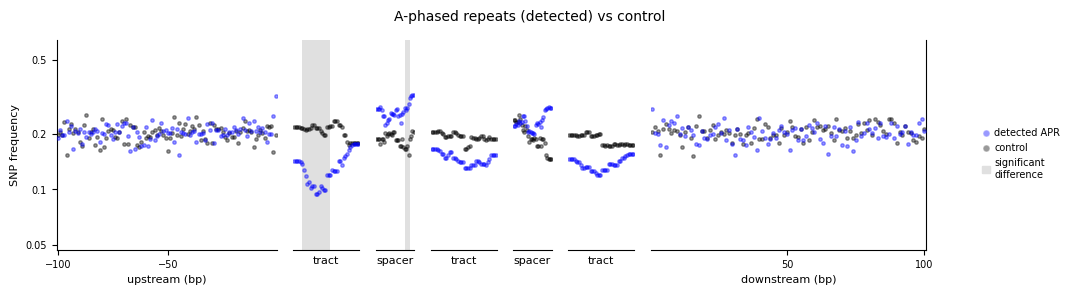

In [22]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

COL_APR  = (0/255, 0/255, 255/255, 0.4)
COL_CTRL = (0/255, 0/255, 0/255, 0.4)
COL_SIG  = (0.88, 0.88, 0.88)
PT_SIZE  = 6
MIN_SIG_RUN = 5

fig = plt.figure(figsize=(11, 3))
gs = gridspec.GridSpec(1, 7, width_ratios=[60, 18, 10.5, 18, 10.5, 18, 75], wspace=0.15,
                       left=0.07, right=0.86, top=0.88, bottom=0.18)

all_vals = np.concatenate([
    left_freq, ctrl_left_freq, right_freq, ctrl_right_freq,
    *part_freqs.values(), *ctrl_part_freqs.values(),
])
valid = all_vals[(all_vals > 0) & np.isfinite(all_vals)]
y_lo = valid.min() * 0.5 if len(valid) else 0.001
y_hi = valid.max() * 2.0 if len(valid) else 1.0
Y_TICKS = [t for t in [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0] if y_lo <= t <= y_hi]
Y_FMT   = ticker.FuncFormatter(lambda x, _: f"{x:g}")

def _filter_short_runs(mask, min_run=MIN_SIG_RUN):
    out = mask.copy(); n = len(out); i = 0
    while i < n:
        if out[i]:
            j = i
            while j < n and out[j]: j += 1
            if j - i < min_run: out[i:j] = False
            i = j
        else:
            i += 1
    return out

def _add_sig_shading(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo, y_hi, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_flank(ax, x, fa, fct, sig, xlabel, show_y, is_left):
    _add_sig_shading(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fa,  s=PT_SIZE, color=COL_APR,  zorder=3)
    ax.set_yscale("log"); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left:
        ax.spines["right"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

def plot_part(ax, fa, fct, sig, xlabel, n_bins):
    x = np.arange(1, n_bins + 1)
    _add_sig_shading(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fa,  s=PT_SIZE, color=COL_APR,  zorder=3)
    ax.set_yscale("log"); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.set_xlim(0.5, n_bins + 0.5); ax.set_xticks([])
    ax.yaxis.set_visible(False)
    for sp in ("left","right","top"): ax.spines[sp].set_visible(False)

ax0 = fig.add_subplot(gs[0])
plot_flank(ax0, left_x, left_freq, ctrl_left_freq, sig_left,
           "upstream (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_part(ax1, part_freqs["Tract1"],  ctrl_part_freqs["Tract1"],  sig_parts["Tract1"],  "tract",  TRACT_BINS)
ax2 = fig.add_subplot(gs[2])
plot_part(ax2, part_freqs["Spacer1"], ctrl_part_freqs["Spacer1"], sig_parts["Spacer1"], "spacer", SPACER_BINS)
ax3 = fig.add_subplot(gs[3])
plot_part(ax3, part_freqs["Tract2"],  ctrl_part_freqs["Tract2"],  sig_parts["Tract2"],  "tract",  TRACT_BINS)
ax4 = fig.add_subplot(gs[4])
plot_part(ax4, part_freqs["Spacer2"], ctrl_part_freqs["Spacer2"], sig_parts["Spacer2"], "spacer", SPACER_BINS)
ax5 = fig.add_subplot(gs[5])
plot_part(ax5, part_freqs["Tract3"],  ctrl_part_freqs["Tract3"],  sig_parts["Tract3"],  "tract",  TRACT_BINS)

ax6 = fig.add_subplot(gs[6])
plot_flank(ax6, right_x, right_freq, ctrl_right_freq, sig_right,
           "downstream (bp)", show_y=False, is_left=False)
ax6.set_xlim(0.5, MAX_FLANK + 0.5); ax6.set_xticks([50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_APR,  markersize=5, label="detected APR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\ndifference"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.99, 0.5),
)
fig.suptitle("A-phased repeats (detected) vs control", fontsize=10, y=0.98)

out_pdf = "apr_snp_frequency_notebook_detected.pdf"
out_png = "apr_snp_frequency_notebook_detected.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf} and {out_png}")
plt.show()

## 6.7b Plot Results (official R IWTomics + ggplot)

Replaces the inline Python permutation test (cells 21 / 22) with the official
**IWTomics** R package (Bioconductor). Three steps:

1. **Run IWTomics in an external R session** — execute the standalone script
   `iwtomics_apr/run_iwtomics_apr.R` in a dedicated R environment. It reads the
   `.intersect` files produced in §6.6 directly, builds per-locus matrices
   for all 7 sub-parts (LeftFlank | Tract1 | Spacer1 | Tract2 | Spacer2 |
   Tract3 | RightFlank), runs `IWTomicsTest` (two-sample mean test,
   B = 1000 permutations, α = 0.01) on each, and saves three `.RData`
   files into the workdir.
2. **Plot in R** with ggplot2 — loads the `.RData` plus per-bin
   SNP-frequency CSVs (which the next cell writes from the same intersect
   files), makes the 7-panel figure, saves to PDF + PNG, and Python
   displays the PNG inline.

R is invoked from `$R_BIN`
(IWTomics + ggplot2/grid/gridExtra). No rpy2 dependency required.


### Running the R script

IWTomics runs outside the notebook, in a dedicated R environment.

1. Make sure cell §6.6 has finished — it produces the two `.intersect` files
   (`NCNRAPhasedRepeats.gnomAD.intersect`,
   `NCNRAPhasedRepeats.gnomAD.ctrl.intersect`) and `split_counts.txt`
   that IWTomics needs.

2. Open a terminal and start R from the dedicated conda env:

   ```bash
   $R_BIN
   ```

3. In the R session, run the script:

   ```text
   /path/to/snp_af_analysis/iwtomics_apr/run_iwtomics_apr.R
   ```

   `source()` the whole file, or run it block by block. APR has 7 sub-parts
   per locus, so IWTomicsTest runs 7 times. The 5 center sub-parts are
   combined into a single `adj_pvalue_curve_center` data.frame with a
   `subpart` column.

   Or run it from a terminal:

   ```bash
   $R_BIN \
     /path/to/snp_af_analysis/iwtomics_apr/run_iwtomics_apr.R
   ```

4. When the script finishes, the workdir of this notebook will contain three
   new files:

   ```
   APhasedRepeats_motif_vs_control_IWTomics_left_0.01.RData
   APhasedRepeats_motif_vs_control_IWTomics_center_0.01.RData
   APhasedRepeats_motif_vs_control_IWTomics_right_0.01.RData
   ```

5. Run the next cell below to produce the 7-panel ggplot figure (it writes
   the per-bin frequency CSVs from the intersect files, then `load()`s the
   three `.RData` files and the CSVs).


N_MOTIF=392  N_CTRL=392
building matrices (motif) …
building matrices (control) …
wrote iwt_freq_{LeftFlank,RightFlank,center}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript …
saved apr_snp_frequency_notebook_iwtomics.{pdf,png}



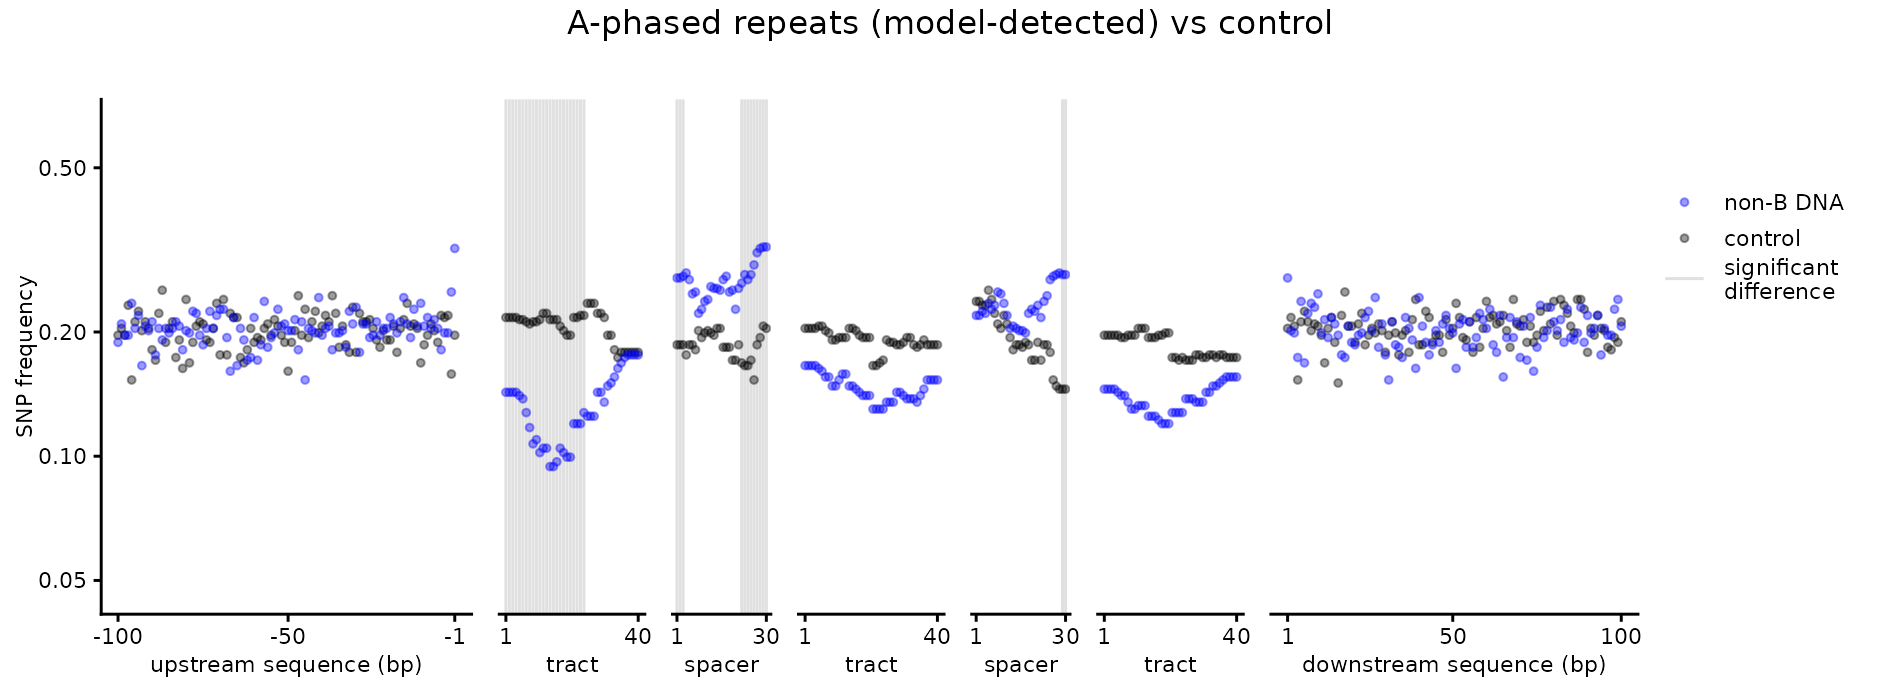

In [47]:
# R + ggplot 7-panel plot using official IWTomics .RData
# Re-builds the per-locus matrices from the .intersect files (same logic as
# cell 21, minus the slow Python permutation that R has now replaced) and
# derives per-bin SNP frequencies, then plots via R + ggplot.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/apr_notebook_detected_run"
os.chdir(WORKDIR)

# parameters (must match run_iwtomics_apr.R)
MAX_FLANK   = 100
TRACT_BINS  = 40
SPACER_BINS = 30
PART_LEN = {"Tract1": TRACT_BINS, "Spacer1": SPACER_BINS,
            "Tract2": TRACT_BINS, "Spacer2": SPACER_BINS,
            "Tract3": TRACT_BINS}
scaledposTract  = [round(i, 4) for i in np.arange(1, TRACT_BINS  * 2, 2.0) / (TRACT_BINS  * 2)]
scaledposSpacer = [round(i, 4) for i in np.arange(1, SPACER_BINS * 2, 2.0) / (SPACER_BINS * 2)]

# N_MOTIF / N_CTRL from split_counts.txt
_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_MOTIF, N_CTRL = _counts["N_MOTIF"], _counts["N_CTRL"]
print(f"N_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")

# build per-locus matrices (mirror of cell 21 _build_matrices, no perm test)
def _build_matrices(intersect_path, n_loci):
    out = {
        "left":    np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "right":   np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "Tract1":  np.zeros((n_loci, TRACT_BINS),  dtype=np.float32),
        "Spacer1": np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "Tract2":  np.zeros((n_loci, TRACT_BINS),  dtype=np.float32),
        "Spacer2": np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "Tract3":  np.zeros((n_loci, TRACT_BINS),  dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype in PART_LEN and plen > 0:
                grid = scaledposTract if ptype.startswith("Tract") else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(grid):
                    if sp >= fs and sp < fe:
                        out[ptype][lid, i] += 1
    return out

print("building matrices (motif) …")
mot = _build_matrices("NCNRAPhasedRepeats.gnomAD.intersect",      N_MOTIF)
print("building matrices (control) …")
ctl = _build_matrices("NCNRAPhasedRepeats.gnomAD.ctrl.intersect", N_CTRL)

# per-bin frequencies → CSVs (one per region)
def _freq(m, n): return m.sum(0) / n

pd.DataFrame({"LeftFlank":  _freq(mot["left"],  N_MOTIF),
              "ctrl_LeftFlank":  _freq(ctl["left"],  N_CTRL)}
             ).to_csv("iwt_freq_LeftFlank.csv",  index=False)
pd.DataFrame({"RightFlank": _freq(mot["right"], N_MOTIF),
              "ctrl_RightFlank": _freq(ctl["right"], N_CTRL)}
             ).to_csv("iwt_freq_RightFlank.csv", index=False)

center_df = {}
for nm in ("Tract1", "Spacer1", "Tract2", "Spacer2", "Tract3"):
    center_df[nm]            = _freq(mot[nm], N_MOTIF)
    center_df[f"ctrl_{nm}"]  = _freq(ctl[nm], N_CTRL)
# Pad short columns (spacers = 30, tracts = 40) to 40 with NA so it's one CSV
maxL = max(PART_LEN.values())
center_padded = {k: np.concatenate([v, np.full(maxL - len(v), np.nan)]) for k, v in center_df.items()}
pd.DataFrame(center_padded).to_csv("iwt_freq_center.csv", index=False)
print("wrote iwt_freq_{LeftFlank,RightFlank,center}.csv")

# R + ggplot
R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/apr_notebook_detected_run")

# load IWTomics significance
load("APhasedRepeats_motif_vs_control_IWTomics_left_0.01.RData")    # adj_pvalue_curve_left
load("APhasedRepeats_motif_vs_control_IWTomics_right_0.01.RData")   # adj_pvalue_curve_right
load("APhasedRepeats_motif_vs_control_IWTomics_center_0.01.RData")  # adj_pvalue_curve_center (subpart col)

freqL <- read.csv("iwt_freq_LeftFlank.csv")    # 100 rows
freqR <- read.csv("iwt_freq_RightFlank.csv")   # 100 rows
freqC <- read.csv("iwt_freq_center.csv")       # 40 rows (spacers padded with NA)

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Freq   = freqL$LeftFlank,
                           C_Freq = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)
RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Freq   = freqR$RightFlank,
                           C_Freq = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

mk_part <- function(name, n_bins) {
  sig_rows <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == name, ]
  data.frame(Levels = seq_len(n_bins),
             Freq   = freqC[[name]][1:n_bins],
             C_Freq = freqC[[paste0("ctrl_", name)]][1:n_bins],
             Signif = sig_rows$significant)
}
T1Df <- mk_part("Tract1",  40)
S1Df <- mk_part("Spacer1", 30)
T2Df <- mk_part("Tract2",  40)
S2Df <- mk_part("Spacer2", 30)
T3Df <- mk_part("Tract3",  40)

allv <- c(LeftFlankDf$Freq,  LeftFlankDf$C_Freq,
          RightFlankDf$Freq, RightFlankDf$C_Freq,
          T1Df$Freq, T1Df$C_Freq, S1Df$Freq, S1Df$C_Freq,
          T2Df$Freq, T2Df$C_Freq, S2Df$Freq, S2Df$C_Freq,
          T3Df$Freq, T3Df$C_Freq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("non-B DNA"               = rgb(t(col2rgb("blue")),  alpha = 100, maxColorValue = 255),
          "significant\ndifference" = "grey88",
          "control"                 = rgb(t(col2rgb("black")), alpha = 100, maxColorValue = 255))

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

base_panel <- function(df, xlab, n_bins) {
  ggplot(df, aes(x = Levels)) +
    geom_vline(xintercept = df$Levels[df$Signif], col = "gray88") +
    geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
    geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
    theme_classic() +
    theme(legend.position = "none",
          axis.text.x  = element_text(size = 8, family = "sans"),
          axis.title.x = element_text(size = 8, family = "sans"),
          axis.title.y = element_blank(),
          axis.text.y  = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line.y  = element_blank()) +
    labs(x = xlab) +
    scale_colour_manual(name = "", values = cols) +
    scale_x_continuous(breaks = c(1, n_bins), limits = c(1, n_bins)) +
    theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
    scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)
}
p2 <- base_panel(T1Df, "tract",  40)
p3 <- base_panel(S1Df, "spacer", 30)
p4 <- base_panel(T2Df, "tract",  40)
p5 <- base_panel(S2Df, "spacer", 30)
p6 <- base_panel(T3Df, "tract",  40)

p7 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\ndifference")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 8, family = "sans"),
        legend.position      = c(1.02, 0.95),
        legend.justification  = c("left", "top"),
        legend.key.height     = unit(0.9, "lines"),
        legend.background     = element_rect(fill = NA, colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("non-B DNA", "control", "significant\ndifference")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 3))

g <- arrangeGrob(p1, p2, p3, p4, p5, p6, p7, ncol = 7,
                 widths = unit(c(60, 22, 16, 22, 16, 22, 80),
                               c("mm","mm","mm","mm","mm","mm","mm")),
                 top = textGrob("A-phased repeats (model-detected) vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("apr_snp_frequency_notebook_iwtomics.pdf", g, width = 9.5, height = 3.4, dpi = 300, bg='white')
ggsave("apr_snp_frequency_notebook_iwtomics.png", g, width = 9.5, height = 3.4, dpi = 200, bg='white')
cat("saved apr_snp_frequency_notebook_iwtomics.{pdf,png}\n")
"""

Path("plot_apr_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} …")
proc = subprocess.run([R_BIN, "--vanilla", "plot_apr_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("apr_snp_frequency_notebook_iwtomics.png"))


## 6.8 Add undetected APR signal

Build the **undetected** APR pool = all `label == 'A_Phased_Repeat'` rows from the test CSV minus the gofae-detected rows. Run the same pipeline (tract detection → NCNR filter → flanks → locuschoice → split → gnomAD intersect → per-locus matrix). The detected/control matrices already in memory are reused as-is.

The new plot overlays three series — **detected (blue)**, **undetected (orange)**, **control (black)** — and the significance shading is the IWTomics test of **detected vs undetected** (not detected vs control).


In [32]:
# 6.8.1 Build the undetected APR pool = all-test minus detected
TEST_CSV = f"{EXPERIMENT_DATA}/A_Phased_Repeat_test.csv"
APR_BED  = f"{PU_RESULTS}/A_Phased_Repeat/A_Phased_Repeat_detected.bed"

# All-test APR (label == 'A_Phased_Repeat'), 0-based half-open
df_all = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","features","label"])
df_all = df_all[df_all["label"] == "A_Phased_Repeat"].copy()
df_all = df_all.dropna(subset=["motif_start","motif_end","features"]).reset_index(drop=True)
df_all["motif_start"] = df_all["motif_start"].astype(int) - 1
df_all["motif_end"]   = df_all["motif_end"].astype(int)
df_all = df_all.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

# Detected coords (re-loaded fresh; 0-based half-open) for the set difference
df_det_min = pd.read_csv(APR_BED, sep="\t", usecols=["chr","motif_start","motif_end"])
df_det_min = df_det_min.dropna().reset_index(drop=True)
df_det_min["motif_start"] = df_det_min["motif_start"].astype(int) - 1
df_det_min["motif_end"]   = df_det_min["motif_end"].astype(int)
df_det_min = df_det_min.drop_duplicates().assign(_is_det=True)

df_undet = df_all.merge(df_det_min, on=["chr","motif_start","motif_end"], how="left")
df_undet = df_undet[df_undet["_is_det"].isna()].drop(columns=["_is_det"]).reset_index(drop=True)
print(f"all-test APR: {len(df_all)}, detected: {len(df_det_min)}, undetected: {len(df_undet)}")

# Sequence (test CSV: features="...sequence=...")
_re_seq = re.compile(r"sequence=([acgtnACGTN]+)")
df_undet["seq"] = df_undet["features"].apply(
    lambda s: _re_seq.search(str(s)).group(1) if _re_seq.search(str(s)) else None)
df_undet = df_undet.dropna(subset=["seq"]).reset_index(drop=True)

# Cascade-regex tract detector defined earlier in cell 7
df_undet["tracts"] = df_undet["seq"].apply(find_tracts)
n_total_u = len(df_undet)
df_undet = df_undet[df_undet["tracts"].notna()].reset_index(drop=True)
print(f"undetected loci with 3 tracts: {len(df_undet)}/{n_total_u} ({100*len(df_undet)/n_total_u:.1f}%)")

df_undet["sections"]  = df_undet["tracts"].apply(
    lambda runs: ",".join(f"{s}|{e}" for (s,e) in runs) + ",")
df_undet["motif_len"] = df_undet["motif_end"] - df_undet["motif_start"]
df_undet = df_undet[df_undet["motif_len"] <= 100].reset_index(drop=True)
print(f"undetected after motif-length<=100 filter: {len(df_undet)}")

df_undet[["chr","motif_start","motif_end","sections"]].to_csv(
    "NCNR.APhasedRepeats.undet.split.bed", sep="\t", header=False, index=False)
print("wrote NCNR.APhasedRepeats.undet.split.bed")


all-test APR: 140624, detected: 3911, undetected: 136713
undetected loci with 3 tracts: 108562/136713 (79.4%)
undetected after motif-length<=100 filter: 108562
wrote NCNR.APhasedRepeats.undet.split.bed


In [33]:
%%bash
set -euo pipefail

# NCNR filter (undetected) — relies on NCNR.hg38.bed already built in cell 9
bedtools intersect -a NCNR.APhasedRepeats.undet.split.bed -b NCNR.hg38.bed -v \
  | bedtools sort -i stdin > NCNR.APhasedRepeats.undet.split.sorted.bed

paste NCNR.APhasedRepeats.undet.split.sorted.bed \
    <(bedtools slop -i NCNR.APhasedRepeats.undet.split.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNRAPhasedRepeats.undet.flanked.bed

wc -l NCNR.APhasedRepeats.undet.split.bed \
      NCNR.APhasedRepeats.undet.split.sorted.bed \
      NCNRAPhasedRepeats.undet.flanked.bed
head -2 NCNRAPhasedRepeats.undet.flanked.bed


 108562 NCNR.APhasedRepeats.undet.split.bed
  50969 NCNR.APhasedRepeats.undet.split.sorted.bed
  50969 NCNRAPhasedRepeats.undet.flanked.bed
 210500 total
chr1	266121	270145	24	+	268121	268145	0|3,11|14,21|24,
chr1	688437	692464	27	+	690437	690464	3|7,13|17,20|22,


In [34]:
# 6.8.2 locuschoice + split + per-chrom gnomAD intersect (undetected)
locuschoice("NCNRAPhasedRepeats.undet.flanked.bed", "NCNRAPhasedRepeats.undet.nooverlap.bed", seed=44)

n_undet = split_apr("NCNRAPhasedRepeats.undet.nooverlap.bed", "NCNRAPhasedRepeats.undet.sections.bed")
N_UNDET = n_undet
print(f"\nN_UNDET={N_UNDET}")

subprocess.run(
    "bedtools sort -i NCNRAPhasedRepeats.undet.sections.bed > _s.bed "
    "&& mv _s.bed NCNRAPhasedRepeats.undet.sections.bed",
    shell=True, check=True,
)
intersect_per_chrom("NCNRAPhasedRepeats.undet.sections.bed",
                    "NCNRAPhasedRepeats.gnomAD.undet.intersect")


NCNRAPhasedRepeats.undet.flanked.bed -> NCNRAPhasedRepeats.undet.nooverlap.bed: kept 45858
NCNRAPhasedRepeats.undet.nooverlap.bed -> NCNRAPhasedRepeats.undet.sections.bed: 45858 Loci, skipped=0

N_UNDET=45858
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNRAPhasedRepeats.undet.sections.bed -> NCNRAPhasedRepeats.gnomAD.undet.intersect: 46232144 lines


46232144

In [39]:
# 6.8.3 Build matrices for undetected, then run IWTomics (detected vs undetected)
print("Building per-locus matrices (undetected) …")
u_left, u_center,u_right = _build_matrices("NCNRAPhasedRepeats.gnomAD.undet.intersect", N_UNDET)

print("IWTomics – left flank (detected vs undetected) …")
sig_dvu_left   = iwtomics(a_left,  u_left)
print(f"  significant positions: {sig_dvu_left.sum()}/{MAX_FLANK}")
print("IWTomics – center (detected vs undetected) …")
sig_dvu_center = iwtomics(a_center, u_center)
print(f"  significant bins: {sig_dvu_center.sum()}/{CENTER_BINS}")
print("IWTomics – right flank (detected vs undetected) …")
sig_dvu_right  = iwtomics(a_right, u_right)
print(f"  significant positions: {sig_dvu_right.sum()}/{MAX_FLANK}")

sig_dvu_parts = {name: sig_dvu_center[off : off + PART_LEN[name]] for name, off in PART_OFFSETS.items()}

undet_left_freq  = u_left.sum(0)  / N_UNDET
undet_right_freq = u_right.sum(0) / N_UNDET
undet_part_freqs = {}
for name, off in PART_OFFSETS.items():
    L = PART_LEN[name]
    undet_part_freqs[name] = u_center[:, off:off+L].sum(0) / N_UNDET

print(f"\nundet flank min/max: {undet_left_freq.min():.4f} .. {undet_right_freq.max():.4f}")


Building per-locus matrices (undetected) …
IWTomics – left flank (detected vs undetected) …
  significant positions: 0/100
IWTomics – center (detected vs undetected) …
  significant bins: 0/180
IWTomics – right flank (detected vs undetected) …
  significant positions: 0/100

undet flank min/max: 0.1870 .. 0.2433


In [40]:
# 6.8.4 Plot — detected (blue) + undetected (orange) + control (black)
# Significance shading = IWTomics(detected vs undetected)
COL_UND = (255/255, 140/255, 0/255, 0.5)   # orange

fig = plt.figure(figsize=(11, 3))
gs = gridspec.GridSpec(1, 7, width_ratios=[60, 18, 10.5, 18, 10.5, 18, 75], wspace=0.15,
                       left=0.07, right=0.86, top=0.88, bottom=0.18)

all_vals2 = np.concatenate([
    left_freq, ctrl_left_freq, right_freq, ctrl_right_freq,
    undet_left_freq, undet_right_freq,
    *part_freqs.values(), *ctrl_part_freqs.values(), *undet_part_freqs.values(),
])
valid2 = all_vals2[(all_vals2 > 0) & np.isfinite(all_vals2)]
y_lo2 = valid2.min() * 0.5 if len(valid2) else 0.001
y_hi2 = valid2.max() * 2.0 if len(valid2) else 1.0
Y_TICKS2 = [t for t in [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0] if y_lo2 <= t <= y_hi2]

def _add_sig_shading2(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo2, y_hi2, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_flank3(ax, x, fa, fct, fu, sig, xlabel, show_y, is_left):
    _add_sig_shading2(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fu,  s=PT_SIZE, color=COL_UND,  zorder=3)
    ax.scatter(x, fa,  s=PT_SIZE, color=COL_APR,  zorder=4)
    ax.set_yscale("log"); ax.set_ylim(y_lo2, y_hi2)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS2))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left: ax.spines["right"].set_visible(False)
    else:       ax.spines["left"].set_visible(False)

def plot_part3(ax, fa, fct, fu, sig, xlabel, n_bins):
    x = np.arange(1, n_bins + 1)
    _add_sig_shading2(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fu,  s=PT_SIZE, color=COL_UND,  zorder=3)
    ax.scatter(x, fa,  s=PT_SIZE, color=COL_APR,  zorder=4)
    ax.set_yscale("log"); ax.set_ylim(y_lo2, y_hi2)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.set_xlim(0.5, n_bins + 0.5); ax.set_xticks([])
    ax.yaxis.set_visible(False)
    for sp in ("left","right","top"): ax.spines[sp].set_visible(False)

ax0 = fig.add_subplot(gs[0])
plot_flank3(ax0, left_x, left_freq, ctrl_left_freq, undet_left_freq, sig_dvu_left,
            "upstream (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_part3(ax1, part_freqs["Tract1"],  ctrl_part_freqs["Tract1"],  undet_part_freqs["Tract1"],
           sig_dvu_parts["Tract1"],  "tract",  TRACT_BINS)
ax2 = fig.add_subplot(gs[2])
plot_part3(ax2, part_freqs["Spacer1"], ctrl_part_freqs["Spacer1"], undet_part_freqs["Spacer1"],
           sig_dvu_parts["Spacer1"], "spacer", SPACER_BINS)
ax3 = fig.add_subplot(gs[3])
plot_part3(ax3, part_freqs["Tract2"],  ctrl_part_freqs["Tract2"],  undet_part_freqs["Tract2"],
           sig_dvu_parts["Tract2"],  "tract",  TRACT_BINS)
ax4 = fig.add_subplot(gs[4])
plot_part3(ax4, part_freqs["Spacer2"], ctrl_part_freqs["Spacer2"], undet_part_freqs["Spacer2"],
           sig_dvu_parts["Spacer2"], "spacer", SPACER_BINS)
ax5 = fig.add_subplot(gs[5])
plot_part3(ax5, part_freqs["Tract3"],  ctrl_part_freqs["Tract3"],  undet_part_freqs["Tract3"],
           sig_dvu_parts["Tract3"],  "tract",  TRACT_BINS)

ax6 = fig.add_subplot(gs[6])
plot_flank3(ax6, right_x, right_freq, ctrl_right_freq, undet_right_freq, sig_dvu_right,
            "downstream (bp)", show_y=False, is_left=False)
ax6.set_xlim(0.5, MAX_FLANK + 0.5); ax6.set_xticks([50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_APR,  markersize=5, label="detected APR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_UND,  markersize=5, label="undetected APR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\n(det vs undet)"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.995, 0.5),
)
fig.suptitle("A-phased repeats: detected vs undetected vs control", fontsize=10, y=0.98)

out_pdf2 = "apr_snp_frequency_notebook_detected_with_undet.pdf"
out_png2 = "apr_snp_frequency_notebook_detected_with_undet.png"
fig.savefig(out_pdf2, dpi=300, bbox_inches="tight")
fig.savefig(out_png2, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf2} and {out_png2}")
plt.show()


## 6.8b Plot detected / undetected / control (official R IWTomics + ggplot)

Re-run §6.8.3 IWTomics significance using the **official IWTomics R Bioconductor package** (Pini & Vantini 2017, IWTomics 1.36) instead of the in-notebook Python permutation `iwtomics()`, then re-plot the 7-panel figure (detected / undetected / control) using `ggplot2`. The blue (detected) and black (control) frequencies stay the same as §6.7b; the new addition is the orange (undetected) series and the gray shading, which is now the official R IWTomics test of **detected vs undetected** at α = 0.01.



### Running the R script

A standalone R script is saved at `iwtomics_apr/run_iwtomics_apr_dvu.R`. It reads `NCNRAPhasedRepeats.gnomAD.intersect` (detected) and `NCNRAPhasedRepeats.gnomAD.undet.intersect` (undetected) directly, builds per-locus matrices for the 7 sub-parts (LeftFlank | Tract1 | Spacer1 | Tract2 | Spacer2 | Tract3 | RightFlank), and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `APhasedRepeats_detected_vs_undetected_IWTomics_left_0.01.RData` -> `adj_pvalue_curve_left`
* `APhasedRepeats_detected_vs_undetected_IWTomics_center_0.01.RData` -> `adj_pvalue_curve_center` (with `subpart` column for the 5 inner parts)
* `APhasedRepeats_detected_vs_undetected_IWTomics_right_0.01.RData` -> `adj_pvalue_curve_right`

Run interactively:

```bash
$R_BIN
> source("/path/to/snp_af_analysis/iwtomics_apr/run_iwtomics_apr_dvu.R")
```

Or batch-run:

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_apr/run_iwtomics_apr_dvu.R
```

`run_iwtomics_apr_dvu.R` will append `N_UNDET` to `split_counts.txt` on the first run so the plotting cell below can pick it up. The undetected pool is much larger than the detected one (~30k+ vs ~400), so reading the 3.5 GB intersect file takes a few minutes and the 7 IWTomicsTest calls take 20-40 min. Once the three `.RData` files are on disk, run the plot cell below.


N_DET=392  N_UNDET=45857  N_CTRL=392
building matrices (detected) ...
building matrices (control) ...
building matrices (undetected -- this is the slow one, ~3.5 GB) ...
wrote iwt_freq_dvu_{LeftFlank,RightFlank,center}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved apr_snp_frequency_notebook_dvu_iwtomics.{pdf,png}



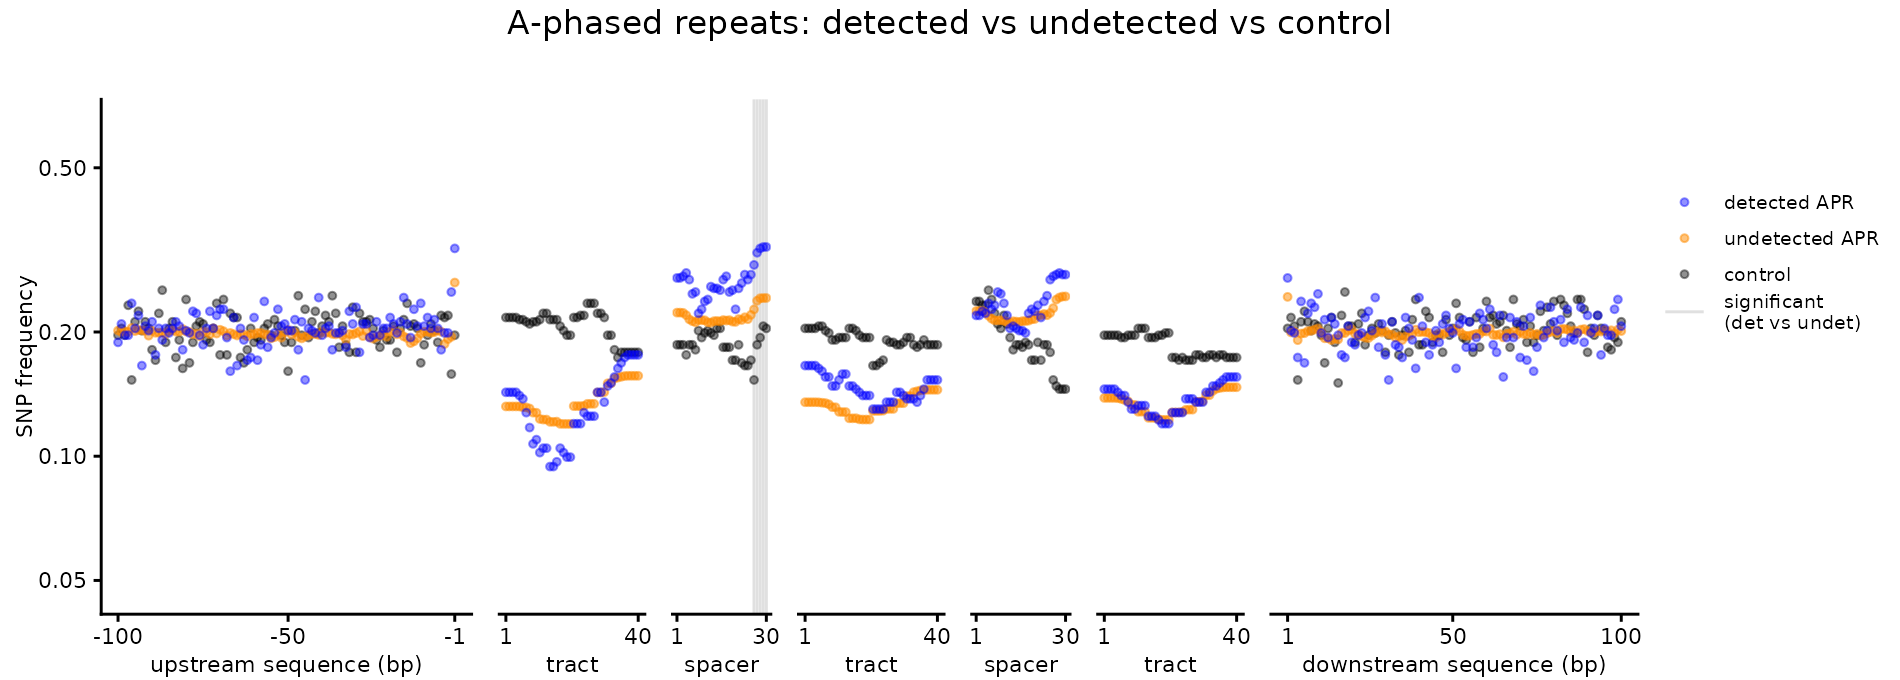

In [46]:
# R + ggplot 7-panel plot, detected / undetected / control
# Rebuilds everything it needs, so it can run on a fresh kernel.
# been run. It re-builds the per-locus matrices for detected / undetected /
# control (mirror of cells 21 + 30, no Python permutation), writes CSVs of
# per-bin SNP frequencies, then plots via R + ggplot.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/apr_notebook_detected_run"
os.chdir(WORKDIR)

# parameters (must match run_iwtomics_apr_dvu.R)
MAX_FLANK   = 100
TRACT_BINS  = 40
SPACER_BINS = 30
PART_LEN = {"Tract1": TRACT_BINS, "Spacer1": SPACER_BINS,
            "Tract2": TRACT_BINS, "Spacer2": SPACER_BINS,
            "Tract3": TRACT_BINS}
scaledposTract  = [round(i, 4) for i in np.arange(1, TRACT_BINS  * 2, 2.0) / (TRACT_BINS  * 2)]
scaledposSpacer = [round(i, 4) for i in np.arange(1, SPACER_BINS * 2, 2.0) / (SPACER_BINS * 2)]

# counts: N_MOTIF, N_CTRL come from split_counts.txt;
# N_UNDET is appended by run_iwtomics_apr_dvu.R
_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_DET, N_CTRL = _counts["N_MOTIF"], _counts["N_CTRL"]
if "N_UNDET" not in _counts:
    raise RuntimeError(
        "N_UNDET not found in split_counts.txt -- run iwtomics_apr/run_iwtomics_apr_dvu.R first "
        "(it appends N_UNDET to split_counts.txt).")
N_UNDET = _counts["N_UNDET"]
print(f"N_DET={N_DET}  N_UNDET={N_UNDET}  N_CTRL={N_CTRL}")

# build per-locus matrices (mirror of cell 21)
def _build_matrices(intersect_path, n_loci):
    out = {
        "left":    np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "right":   np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "Tract1":  np.zeros((n_loci, TRACT_BINS),  dtype=np.float32),
        "Spacer1": np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "Tract2":  np.zeros((n_loci, TRACT_BINS),  dtype=np.float32),
        "Spacer2": np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "Tract3":  np.zeros((n_loci, TRACT_BINS),  dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype in PART_LEN and plen > 0:
                grid = scaledposTract if ptype.startswith("Tract") else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(grid):
                    if sp >= fs and sp < fe:
                        out[ptype][lid, i] += 1
    return out

print("building matrices (detected) ...")
det = _build_matrices("NCNRAPhasedRepeats.gnomAD.intersect",      N_DET)
print("building matrices (control) ...")
ctl = _build_matrices("NCNRAPhasedRepeats.gnomAD.ctrl.intersect", N_CTRL)
print("building matrices (undetected -- this is the slow one, ~3.5 GB) ...")
und = _build_matrices("NCNRAPhasedRepeats.gnomAD.undet.intersect", N_UNDET)

# per-bin frequencies -> CSVs
def _freq(m, n): return m.sum(0) / n

pd.DataFrame({
    "LeftFlank":       _freq(det["left"],  N_DET),
    "ctrl_LeftFlank":  _freq(ctl["left"],  N_CTRL),
    "undet_LeftFlank": _freq(und["left"],  N_UNDET),
}).to_csv("iwt_freq_dvu_LeftFlank.csv",  index=False)

pd.DataFrame({
    "RightFlank":       _freq(det["right"], N_DET),
    "ctrl_RightFlank":  _freq(ctl["right"], N_CTRL),
    "undet_RightFlank": _freq(und["right"], N_UNDET),
}).to_csv("iwt_freq_dvu_RightFlank.csv", index=False)

center_df = {}
for nm in ("Tract1", "Spacer1", "Tract2", "Spacer2", "Tract3"):
    center_df[nm]              = _freq(det[nm], N_DET)
    center_df[f"ctrl_{nm}"]    = _freq(ctl[nm], N_CTRL)
    center_df[f"undet_{nm}"]   = _freq(und[nm], N_UNDET)
maxL = max(PART_LEN.values())
center_padded = {k: np.concatenate([v, np.full(maxL - len(v), np.nan)]) for k, v in center_df.items()}
pd.DataFrame(center_padded).to_csv("iwt_freq_dvu_center.csv", index=False)
print("wrote iwt_freq_dvu_{LeftFlank,RightFlank,center}.csv")

# R + ggplot
R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/apr_notebook_detected_run")

load("APhasedRepeats_detected_vs_undetected_IWTomics_left_0.01.RData")
load("APhasedRepeats_detected_vs_undetected_IWTomics_right_0.01.RData")
load("APhasedRepeats_detected_vs_undetected_IWTomics_center_0.01.RData")

freqL <- read.csv("iwt_freq_dvu_LeftFlank.csv")
freqR <- read.csv("iwt_freq_dvu_RightFlank.csv")
freqC <- read.csv("iwt_freq_dvu_center.csv")

LeftFlankDf <- data.frame(
  Levels  = seq(-100, -1, 1),
  Det     = freqL$LeftFlank,
  Und     = freqL$undet_LeftFlank,
  Ctrl    = freqL$ctrl_LeftFlank,
  Signif  = adj_pvalue_curve_left$significant
)
RightFlankDf <- data.frame(
  Levels  = seq(1, 100, 1),
  Det     = freqR$RightFlank,
  Und     = freqR$undet_RightFlank,
  Ctrl    = freqR$ctrl_RightFlank,
  Signif  = adj_pvalue_curve_right$significant
)

mk_part <- function(name, n_bins) {
  sig_rows <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == name, ]
  data.frame(
    Levels  = seq_len(n_bins),
    Det     = freqC[[name]][1:n_bins],
    Und     = freqC[[paste0("undet_", name)]][1:n_bins],
    Ctrl    = freqC[[paste0("ctrl_",  name)]][1:n_bins],
    Signif  = sig_rows$significant
  )
}
T1Df <- mk_part("Tract1",  40)
S1Df <- mk_part("Spacer1", 30)
T2Df <- mk_part("Tract2",  40)
S2Df <- mk_part("Spacer2", 30)
T3Df <- mk_part("Tract3",  40)

allv <- c(LeftFlankDf$Det, LeftFlankDf$Und, LeftFlankDf$Ctrl,
          RightFlankDf$Det, RightFlankDf$Und, RightFlankDf$Ctrl,
          T1Df$Det, T1Df$Und, T1Df$Ctrl,
          S1Df$Det, S1Df$Und, S1Df$Ctrl,
          T2Df$Det, T2Df$Und, T2Df$Ctrl,
          S2Df$Det, S2Df$Und, S2Df$Ctrl,
          T3Df$Det, T3Df$Und, T3Df$Ctrl)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c(
  "detected APR"            = rgb(t(col2rgb("blue")),    alpha = 110, maxColorValue = 255),
  "undetected APR"          = rgb(t(col2rgb("darkorange")), alpha = 130, maxColorValue = 255),
  "control"                 = rgb(t(col2rgb("black")),   alpha = 110, maxColorValue = 255),
  "significant\n(det vs undet)" = "grey88"
)

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),        size = 1) +
  geom_point(aes(y = Und,  col = "undetected APR"), size = 1) +
  geom_point(aes(y = Det,  col = "detected APR"),   size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

base_panel <- function(df, xlab, n_bins) {
  ggplot(df, aes(x = Levels)) +
    geom_vline(xintercept = df$Levels[df$Signif], col = "gray88") +
    geom_point(aes(y = Ctrl, col = "control"),        size = 1) +
    geom_point(aes(y = Und,  col = "undetected APR"), size = 1) +
    geom_point(aes(y = Det,  col = "detected APR"),   size = 1) +
    theme_classic() +
    theme(legend.position = "none",
          axis.text.x  = element_text(size = 8, family = "sans"),
          axis.title.x = element_text(size = 8, family = "sans"),
          axis.title.y = element_blank(),
          axis.text.y  = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line.y  = element_blank()) +
    labs(x = xlab) +
    scale_colour_manual(name = "", values = cols) +
    scale_x_continuous(breaks = c(1, n_bins), limits = c(1, n_bins)) +
    theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
    scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)
}
p2 <- base_panel(T1Df, "tract",  40)
p3 <- base_panel(S1Df, "spacer", 30)
p4 <- base_panel(T2Df, "tract",  40)
p5 <- base_panel(S2Df, "spacer", 30)
p6 <- base_panel(T3Df, "tract",  40)

p7 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\n(det vs undet)")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),        size = 1) +
  geom_point(aes(y = Und,  col = "undetected APR"), size = 1) +
  geom_point(aes(y = Det,  col = "detected APR"),   size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 7, family = "sans"),
        legend.position      = c(1.02, 0.95),
        legend.justification  = c("left", "top"),
        legend.key.height     = unit(0.9, "lines"),
        legend.background     = element_rect(fill = NA, colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("detected APR", "undetected APR", "control",
                                 "significant\n(det vs undet)")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 4))

g <- arrangeGrob(p1, p2, p3, p4, p5, p6, p7, ncol = 7,
                 widths = unit(c(60, 22, 16, 22, 16, 22, 80),
                               c("mm","mm","mm","mm","mm","mm","mm")),
                 top = textGrob("A-phased repeats: detected vs undetected vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("apr_snp_frequency_notebook_dvu_iwtomics.pdf", g, width = 9.5, height = 3.4, dpi = 300,bg='white')
ggsave("apr_snp_frequency_notebook_dvu_iwtomics.png", g, width = 9.5, height = 3.4, dpi = 200,bg='white')
cat("saved apr_snp_frequency_notebook_dvu_iwtomics.{pdf,png}\n")
"""

Path("plot_apr_dvu_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_apr_dvu_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("apr_snp_frequency_notebook_dvu_iwtomics.png"))
